# Preprocess parking images (grayscale, filtering, thresholding)

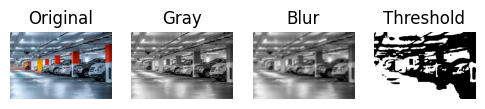

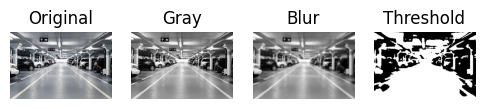

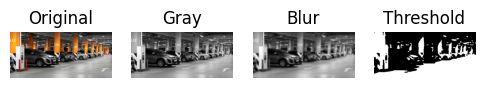

In [1]:
import cv2
import matplotlib.pyplot as plt

paths = [
"/content/drive/MyDrive/OD_EndSemLab/park1.jpg",
"/content/drive/MyDrive/OD_EndSemLab/park2.jpg",
"/content/drive/MyDrive/OD_EndSemLab/park3.jpg"
]

for p in paths:
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(g,(5,5),0)
    _, th = cv2.threshold(blur,127,255,cv2.THRESH_BINARY)

    plt.figure(figsize=(6,4))
    for i,(t,im) in enumerate(zip(
        ["Original","Gray","Blur","Threshold"],
        [img,g,blur,th])):
        plt.subplot(1,4,i+1)
        plt.imshow(im,cmap='gray' if i>0 else None)
        plt.title(t)
        plt.axis('off')
    plt.show()

# **Apply HOG + sliding window to detect vehicles**

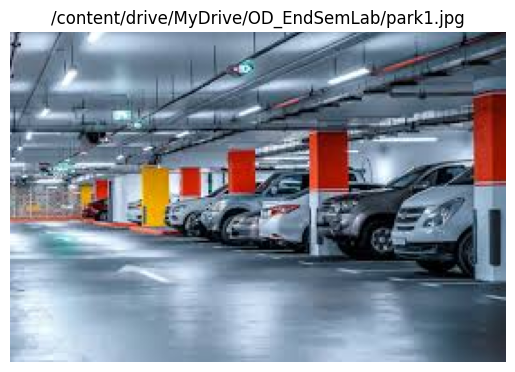

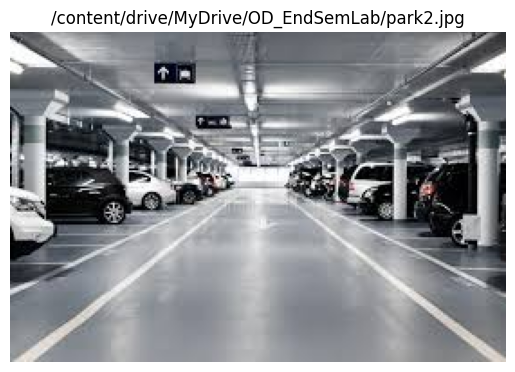

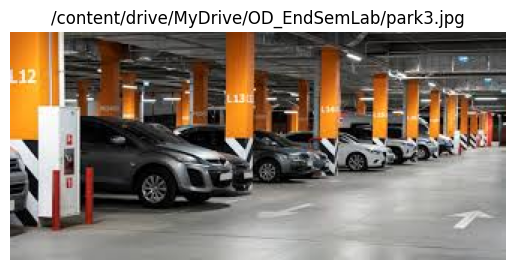

In [3]:
import cv2
import matplotlib.pyplot as plt

paths = [
"/content/drive/MyDrive/OD_EndSemLab/park1.jpg",
"/content/drive/MyDrive/OD_EndSemLab/park2.jpg",
"/content/drive/MyDrive/OD_EndSemLab/park3.jpg"
]

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

for p in paths:
    img = cv2.imread(p)
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    for y in range(0,g.shape[0],32):
        for x in range(0,g.shape[1],32):
            w = g[y:y+128, x:x+64]
            if w.shape[:2]!=(128,64): continue
            r,_ = hog.detectMultiScale(w)
            for (i,j,w1,h1) in r:
                cv2.rectangle(img,(x+i,y+j),(x+i+w1,y+j+h1),(0,255,0),2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(p)
    plt.axis('off')
    plt.show()

# Visualize detected parking slots using bounding boxes.

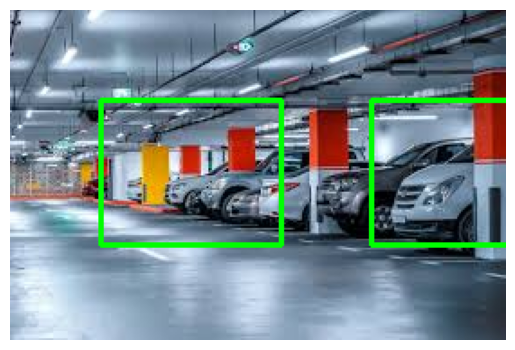

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/OD_EndSemLab/park1.jpg")

slots = [(50,50,100,80),(200,50,100,80),(350,50,100,80)]

for (x,y,w,h) in slots:
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Implement YOLO/SSD for parking detection

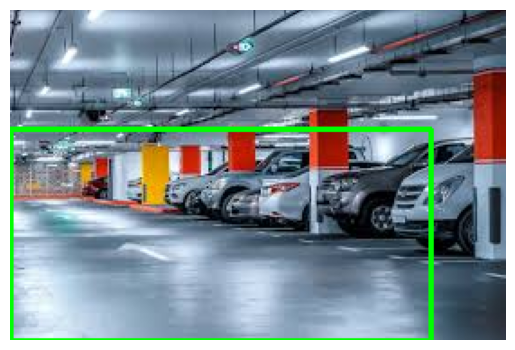

In [11]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/OD_EndSemLab/park1.jpg")
g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(g,(5,5),0)
_,th = cv2.threshold(blur,127,255,cv2.THRESH_BINARY)

contours,_ = cv2.findContours(th,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

for c in contours:
    x,y,w,h = cv2.boundingRect(c)
    if w>50 and h>50:
        cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Evaluate using IoU and precision

In [12]:
def iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[0]+a[2],b[0]+b[2])
    y2=min(a[1]+a[3],b[1]+b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    return inter/(a[2]*a[3]+b[2]*b[3]-inter)

gt = [(50,50,100,80)]
pred = [(55,55,95,75)]

tp = sum(1 for p in pred for g in gt if iou(p,g)>0.5)
fp = len(pred)-tp
precision = tp/(tp+fp)

print("IoU:", iou(gt[0],pred[0]))
print("Precision:", precision)

IoU: 0.890625
Precision: 1.0


# Analyze performance under lighting/weather variations

In [13]:
import cv2

img = cv2.imread("/content/drive/MyDrive/OD_EndSemLab/park1.jpg")
g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

bright = cv2.convertScaleAbs(g,alpha=1.5,beta=50)
dark = cv2.convertScaleAbs(g,alpha=0.5,beta=-50)

_,t1 = cv2.threshold(bright,127,255,cv2.THRESH_BINARY)
_,t2 = cv2.threshold(dark,127,255,cv2.THRESH_BINARY)

print("Bright pixels:",cv2.countNonZero(t1))
print("Dark pixels:",cv2.countNonZero(t2))

Bright pixels: 45561
Dark pixels: 0
